In [ ]:
conda install matplotlib

In [ ]:
conda install pandas

In [3]:
conda install seaborn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.944 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ patsy          1.0.3    py313h1804a44_0      emscripten-forge-4x
+ python-tzdata  2026.5   pyh5ded981_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.2.1   pyh145f28c_0         conda-forge


In [4]:
conda install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.437 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.20       pyh5ded981_0         conda-forge
+ joblib              1.6.0      py313h57e9779_0      emscripten-forge-4x
+ narwhals            2.27.0     pyh5ded981_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools       

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from scipy import stats
from sklearn.impute import SimpleImputer

In [6]:
df=pd.read_csv("original_dataset.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [8]:
print("Original Dataset")
print("Rows :",df.shape[0])
print("Columns :",df.shape[0])

Original Dataset
Rows : 1200
Columns : 1200


In [10]:
print("Columns :\n",df.columns)

Columns :
 Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')


In [12]:
print("Column data types :",df.dtypes)

Column data types : OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object


In [14]:
#Missing value analysis
print("Null count before missing value handling\n")
df.isnull().sum()

Null count before missing value handling



OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [15]:
df["CouponCode"].value_counts(dropna=False)

CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [19]:
#Missing value handling
df['CouponCode']=df['CouponCode'].fillna("No coupon")

In [20]:
numerical_cols=df.select_dtypes(include=np.number).columns
if df[numerical_cols].isnull().sum().sum()>0:
    imputer=SimpleImputer(strategy='median')
    df[numerical_cols]=imputer.fit_transform(df[numerical_cols])
    print("\nMedian imputation applied")
else:
    print("\nNo missing numerical values. Median imputation not required")


No missing numerical values. Median imputation not required


In [21]:
print(numerical_cols)

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='str')


In [23]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(col,"-",len(outliers),"outliers")

Quantity - 0 outliers
UnitPrice - 0 outliers
ItemsInCart - 0 outliers
TotalPrice - 8 outliers


In [24]:
totalprice_outliers = df[(df["TotalPrice"] < lower_bound) |(df["TotalPrice"] > upper_bound)]
totalprice_outliers[["OrderID", "Product", "Quantity", "UnitPrice", "TotalPrice"]]

,OrderID,Product,Quantity,UnitPrice,TotalPrice
107,ORD200107,Printer,5,670.75,3353.75
326,ORD200326,Laptop,5,670.48,3352.40
328,ORD200328,Tablet,5,674.04,3370.20
469,ORD200469,Chair,5,676.98,3384.90
632,ORD200632,Laptop,5,678.16,3390.80
789,ORD200789,Tablet,5,691.28,3456.40
1065,ORD201065,Printer,5,666.80,3334.00
1122,ORD201122,Monitor,5,678.19,3390.95


In [25]:
calc_total = np.isclose(df["TotalPrice"],df["Quantity"] * df["UnitPrice"])
pd.Series(calc_total).value_counts()

True    1200
Name: count, dtype: int64

In [26]:
for col in ['ReferralSource','OrderStatus','PaymentMethod']:
    print("\n")
    print(df[col].value_counts())



ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [28]:
#Feature engineering
df["Date"] = pd.to_datetime(df["Date"])
df["OrderYear"] = df["Date"].dt.year
df["OrderMonth"] = df["Date"].dt.month_name()
df["OrderDay"] = df["Date"].dt.day_name()
df["IsWeekend"] = df["Date"].dt.dayofweek >= 5
df[["Date","OrderYear","OrderMonth","OrderDay","IsWeekend"]].head()

,Date,OrderYear,OrderMonth,OrderDay,IsWeekend
0,2023-01-04,2023,January,Wednesday,False
1,2024-08-23,2024,August,Friday,False
2,2024-02-27,2024,February,Tuesday,False
3,2023-10-15,2023,October,Sunday,True
4,2025-05-08,2025,May,Thursday,False


In [29]:
df["CouponUsed"] = df["CouponCode"] != "No Coupon"

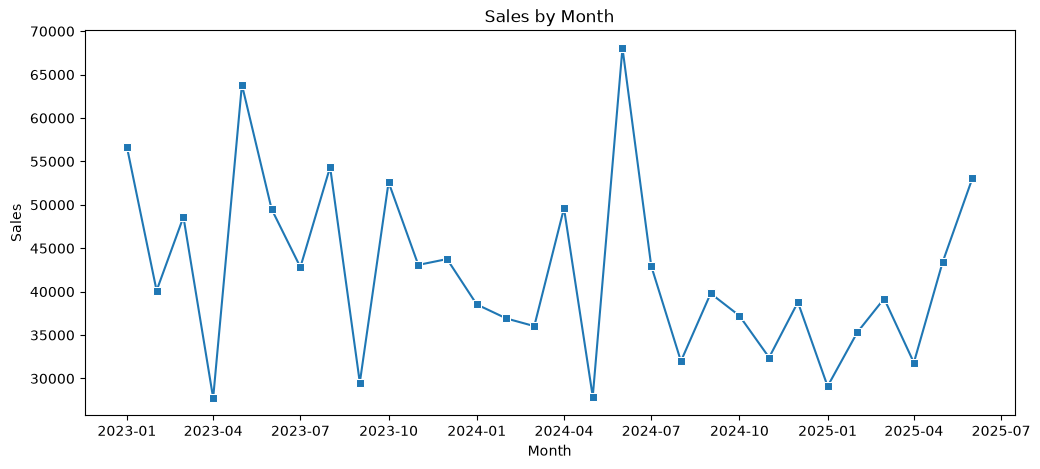

In [42]:
#Exploratory data analysis
sales_by_month = (df.groupby(df["Date"].dt.to_period("M"))["TotalPrice"].sum())
sales_by_month.index = sales_by_month.index.to_timestamp()
plt.figure(figsize=(12, 5))
sns.lineplot(x=sales_by_month.index,y=sales_by_month.values,marker="s")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

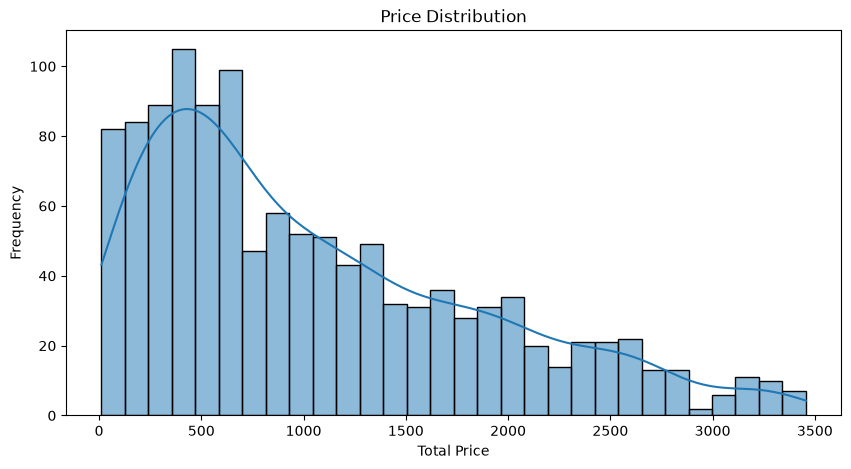

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(df["TotalPrice"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

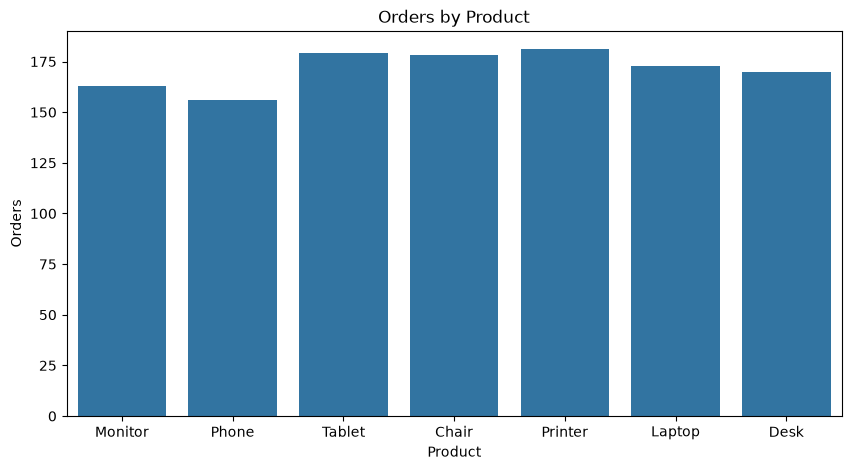

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Product")
plt.title("Orders by Product")
plt.xlabel("Product")
plt.ylabel("Orders")
plt.show()

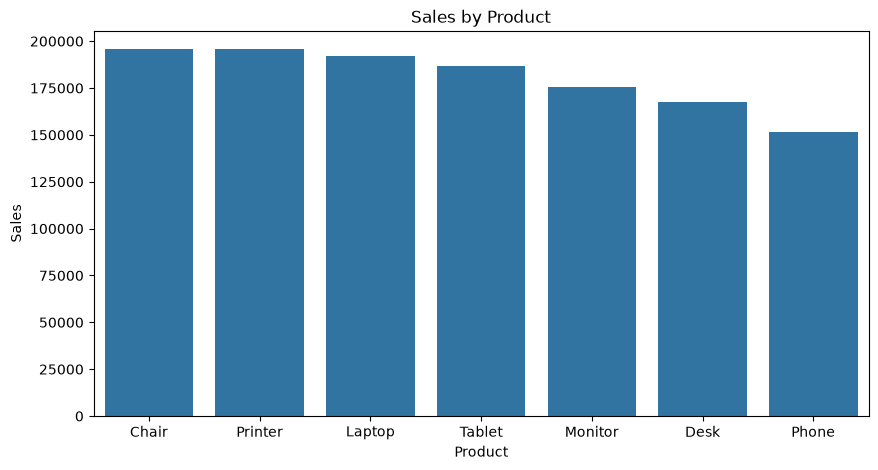

In [36]:
sales_by_product = (df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False))
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_product.index,y=sales_by_product.values)
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

In [37]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,OrderYear
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,2023.767500
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,2023.000000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,2023.000000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,2024.000000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,2024.000000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,2025.000000
std,NaN,1.407557,197.177146,2.281983,819.856558,0.750942


In [38]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
OrderYear          0
OrderMonth         0
OrderDay           0
IsWeekend          0
CouponUsed         0
dtype: int64

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
 14  OrderYear        1200 non-null   int32         
 15

In [40]:
df.shape

(1200, 19)

In [41]:
df.to_csv("cleaned_dataset.csv", index=False)